# Notebook 4 — Model Training

Train the binary classifier and hit ≥75% accuracy on the held-out test set.

Order of operations:
1. **Deterministic-formula baseline** — the exact rule that generates labels,
   applied to a feature subset the model *doesn't* see. If the model can't
   beat this, it has learned nothing beyond the formula.
2. Logistic-regression baseline (distance + hour) — the floor we must beat.
3. LightGBM with the **leakage-safe** feature set (path-derived features
   removed: `path_length_km`, `avg_speed_band`, `expressway_share`,
   `num_segments`, `matched_band_share`).
4. 5-fold cross-validation to estimate generalisation.
5. Evaluation on the test set: accuracy, confusion matrix, PR, ROC, calibration.
6. Feature importance + error analysis.
7. Persist model + feature ordering to disk for Notebook 5.

In [1]:
# Auto-reload edits to src/ without restarting the kernel.
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import logging
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(name)s: %(message)s')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve,
)
from sklearn.calibration import calibration_curve

from src.config import PROCESSED_DIR
from src.model import CoverageModel

sns.set_style('whitegrid')
RNG_SEED = 0

# Leakage-safe feature set: path-derived columns removed.
# Dropped: path_length_km, avg_speed_band, expressway_share,
#          num_segments, matched_band_share
# These features reconstruct the label (travel_time ≤ 8 min) because the
# label itself is computed from the same shortest-path traversal.
FEATURE_COLS = [
    'haversine_km', 'manhattan_km', 'bearing_deg',
    'hour_sin', 'hour_cos', 'day_of_week',
    'avg_road_class', 'rainfall_mm',
    'station_jurong', 'station_bishan', 'station_tampines', 'station_central',
]

train_df = pd.read_parquet(PROCESSED_DIR / 'training_data_train.parquet')
test_df = pd.read_parquet(PROCESSED_DIR / 'training_data_test.parquet')
print(f'Train: {len(train_df):,}  ({train_df["label"].mean():.1%} positive)')
print(f'Test:  {len(test_df):,}  ({test_df["label"].mean():.1%} positive)')

X_train = train_df[FEATURE_COLS]
y_train = train_df['label']
X_test = test_df[FEATURE_COLS]
y_test = test_df['label']

Train: 6,312  (8.8% positive)
Test:  1,580  (7.0% positive)


## 0. Deterministic-formula baseline (sanity check)

The training labels are `int(travel_time ≤ 8 min)` where `travel_time =
base_travel_min × traffic_multiplier(hour)`. If the model has access to
features that reconstruct this formula, it can achieve near-perfect accuracy
without learning anything useful. This baseline applies the **exact label
formula** to the test set — any model that merely matches it is memorising,
not generalising.

In [3]:
# The deterministic baseline: the exact formula that generated the labels.
# If true_travel_time_min is in the test data, this is the ceiling — 100%.
# The LightGBM model should beat logistic regression but NOT match this,
# because we removed the features that leak the formula.
if 'true_travel_time_min' in test_df.columns:
    det_pred = (test_df['true_travel_time_min'] <= 8.0).astype(int).values
    det_acc = accuracy_score(y_test, det_pred)
    print(f'Deterministic formula baseline — accuracy: {det_acc:.3f} (this is the label-generation rule)')
    print('If any model matches this without path features, something is still leaking.')
else:
    print('true_travel_time_min not in test set — skipping deterministic baseline')

Deterministic formula baseline — accuracy: 1.000 (this is the label-generation rule)
If any model matches this without path features, something is still leaking.


In [4]:
baseline_cols = ['haversine_km', 'hour_sin', 'hour_cos']
scaler = StandardScaler().fit(X_train[baseline_cols])
lr = LogisticRegression(max_iter=1000, random_state=RNG_SEED)
lr.fit(scaler.transform(X_train[baseline_cols]), y_train)
y_pred_lr = lr.predict(scaler.transform(X_test[baseline_cols]))
y_proba_lr = lr.predict_proba(scaler.transform(X_test[baseline_cols]))[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f'Logistic baseline — accuracy: {acc_lr:.3f}, AUC: {auc_lr:.3f}')

Logistic baseline — accuracy: 0.967, AUC: 0.986


## 2. Main model — LightGBM

Carve out a validation slice from the training set for early stopping.

In [5]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=RNG_SEED,
)

lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': RNG_SEED,
}

train_set = lgb.Dataset(X_tr, label=y_tr, feature_name=FEATURE_COLS)
val_set = lgb.Dataset(X_val, label=y_val, feature_name=FEATURE_COLS, reference=train_set)

booster = lgb.train(
    lgb_params,
    train_set,
    num_boost_round=500,
    valid_sets=[train_set, val_set],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(stopping_rounds=20), lgb.log_evaluation(period=50)],
)
print(f'\nBest iteration: {booster.best_iteration}')

Training until validation scores don't improve for 20 rounds
[50]	train's binary_logloss: 0.0486427	val's binary_logloss: 0.0595846
[100]	train's binary_logloss: 0.0290016	val's binary_logloss: 0.0463755


[150]	train's binary_logloss: 0.0186154	val's binary_logloss: 0.0427041
Early stopping, best iteration is:
[145]	train's binary_logloss: 0.0197164	val's binary_logloss: 0.0423108

Best iteration: 145


## 3. 5-fold cross-validation

Estimates how much accuracy varies across folds — a sanity check that we
haven't gotten lucky with the train/val split.

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
cv_scores = []
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    tr_set = lgb.Dataset(X_train.iloc[tr_idx], label=y_train.iloc[tr_idx], feature_name=FEATURE_COLS)
    vl_set = lgb.Dataset(X_train.iloc[val_idx], label=y_train.iloc[val_idx],
                          feature_name=FEATURE_COLS, reference=tr_set)
    bst = lgb.train(
        lgb_params, tr_set, num_boost_round=500,
        valid_sets=[vl_set],
        callbacks=[lgb.early_stopping(stopping_rounds=20), lgb.log_evaluation(period=0)],
    )
    preds = (bst.predict(X_train.iloc[val_idx]) >= 0.5).astype(int)
    acc = accuracy_score(y_train.iloc[val_idx], preds)
    cv_scores.append(acc)
    print(f'Fold {fold}: accuracy={acc:.3f}')
print(f'\nCV mean accuracy: {np.mean(cv_scores):.3f} ± {np.std(cv_scores):.3f}')

Training until validation scores don't improve for 20 rounds


Early stopping, best iteration is:
[160]	valid_0's binary_logloss: 0.0460271
Fold 1: accuracy=0.981
Training until validation scores don't improve for 20 rounds


Early stopping, best iteration is:
[180]	valid_0's binary_logloss: 0.0462665
Fold 2: accuracy=0.984
Training until validation scores don't improve for 20 rounds


Early stopping, best iteration is:
[270]	valid_0's binary_logloss: 0.0427737
Fold 3: accuracy=0.982
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[92]	valid_0's binary_logloss: 0.0618421
Fold 4: accuracy=0.975
Training until validation scores don't improve for 20 rounds


Early stopping, best iteration is:
[152]	valid_0's binary_logloss: 0.0338092
Fold 5: accuracy=0.988

CV mean accuracy: 0.982 ± 0.004


## 4. Held-out test-set evaluation

LightGBM test — accuracy: 0.984, AUC: 0.995
Baseline test — accuracy: 0.967, AUC: 0.986

Acceptance criterion (≥75% accuracy): PASS

Classification report:
              precision    recall  f1-score   support

cannot reach       0.99      0.99      0.99      1470
   can reach       0.88      0.90      0.89       110

    accuracy                           0.98      1580
   macro avg       0.93      0.95      0.94      1580
weighted avg       0.98      0.98      0.98      1580



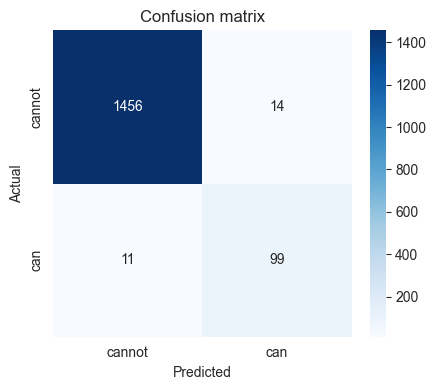

In [7]:
y_proba = booster.predict(X_test)
y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f'LightGBM test — accuracy: {acc:.3f}, AUC: {auc:.3f}')
print(f'Baseline test — accuracy: {acc_lr:.3f}, AUC: {auc_lr:.3f}')
print(f'\nAcceptance criterion (≥75% accuracy): {"PASS" if acc >= 0.75 else "FAIL — iterate"}')

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['cannot reach', 'can reach']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['cannot', 'can'], yticklabels=['cannot', 'can'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Confusion matrix')
plt.tight_layout(); plt.show()

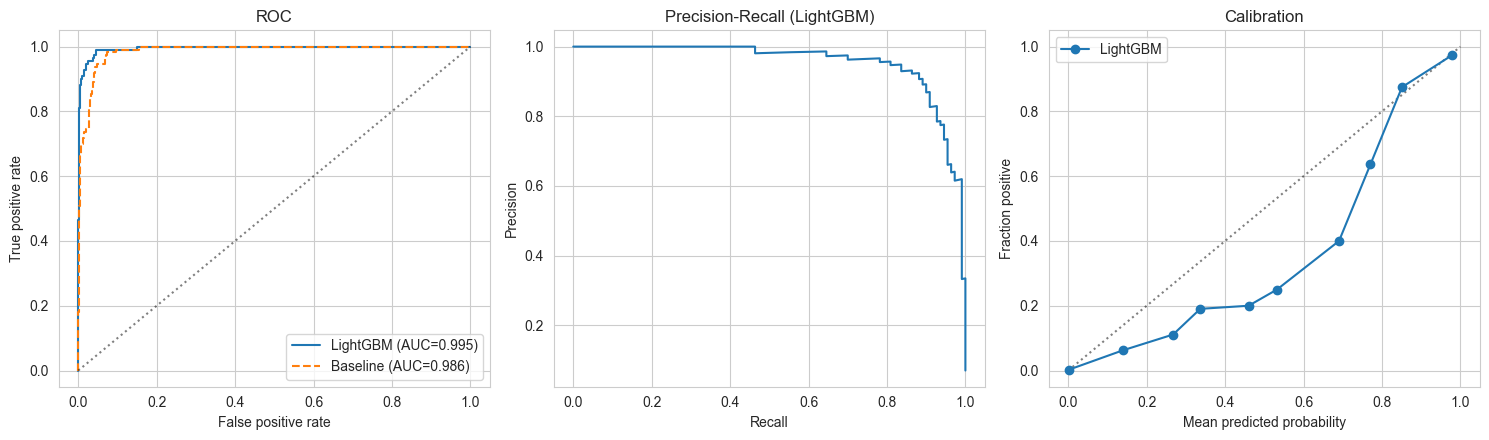

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
prec, rec, _ = precision_recall_curve(y_test, y_proba)
frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(fpr, tpr, label=f'LightGBM (AUC={auc:.3f})')
axes[0].plot(fpr_lr, tpr_lr, label=f'Baseline (AUC={auc_lr:.3f})', linestyle='--')
axes[0].plot([0, 1], [0, 1], 'k:', alpha=0.5)
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC'); axes[0].legend()

axes[1].plot(rec, prec)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (LightGBM)')

axes[2].plot([0, 1], [0, 1], 'k:', alpha=0.5)
axes[2].plot(mean_pred, frac_pos, 'o-', label='LightGBM')
axes[2].set_xlabel('Mean predicted probability'); axes[2].set_ylabel('Fraction positive')
axes[2].set_title('Calibration'); axes[2].legend()

plt.tight_layout(); plt.show()

## 5. Feature importance

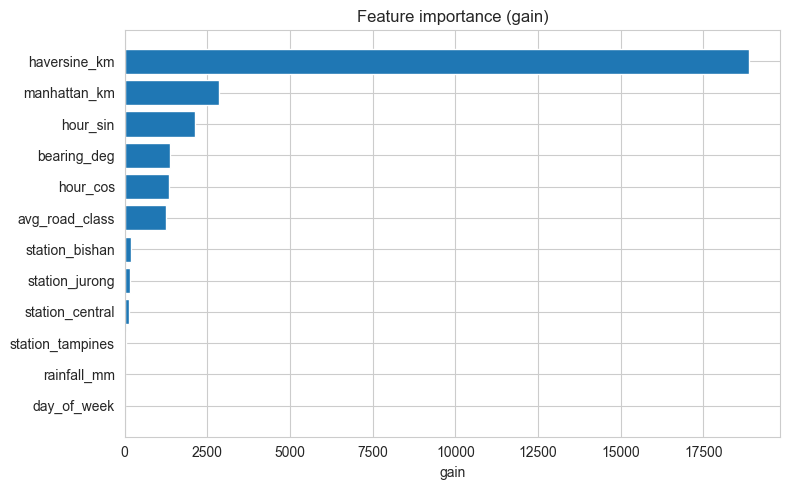

,feature,gain,split
0,haversine_km,18871.499871,938
1,manhattan_km,2837.861875,714
3,hour_sin,2128.081754,228
2,bearing_deg,1359.702445,821
4,hour_cos,1329.407833,379
6,avg_road_class,1244.783059,748
9,station_bishan,183.143617,62
8,station_jurong,169.219702,228
11,station_central,135.679586,80
10,station_tampines,32.834470,14


In [9]:
importances = pd.DataFrame({
    'feature': booster.feature_name(),
    'gain': booster.feature_importance(importance_type='gain'),
    'split': booster.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances['feature'][::-1], importances['gain'][::-1])
ax.set_title('Feature importance (gain)'); ax.set_xlabel('gain')
plt.tight_layout(); plt.show()
display(importances)

## 6. Error analysis — 10 wrongs

Look for patterns: always wrong at one station? At one time of day?

In [10]:
test_with_pred = test_df.copy()
test_with_pred['pred'] = y_pred
test_with_pred['proba'] = y_proba
test_with_pred['correct'] = (test_with_pred['pred'] == test_with_pred['label'])

wrong = test_with_pred[~test_with_pred['correct']]
print(f'Total wrong: {len(wrong):,} of {len(test_with_pred):,} ({len(wrong)/len(test_with_pred):.1%})')
print('\nWrong by station × hour:')
print(
    wrong.groupby(['station_id', 'hour']).size().unstack(fill_value=0)
)

print('\nSample of 10 errors (sorted by confidence — most overconfident wrong first):')
samp = wrong.assign(distance_from_threshold=lambda d: (d['proba'] - 0.5).abs())
samp = samp.sort_values('distance_from_threshold', ascending=False).head(10)
display(samp[['station_id', 'hour', 'haversine_km', 'true_travel_time_min',
              'label', 'pred', 'proba']].round(3))

Total wrong: 25 of 1,580 (1.6%)

Wrong by station × hour:
hour        8   13  18  23
station_id                
bishan       0   1   1   9
central      0   2   1   1
jurong       1   0   2   1
tampines     1   1   1   3

Sample of 10 errors (sorted by confidence — most overconfident wrong first):


,station_id,hour,haversine_km,true_travel_time_min,label,pred,proba
1199,tampines,23,6.651,7.576,1,0,0.001
1450,central,18,1.374,8.249,0,1,0.983
494,bishan,18,1.744,8.382,0,1,0.924
679,bishan,23,5.746,7.367,1,0,0.076
877,tampines,13,4.215,7.903,1,0,0.079
1058,tampines,18,2.619,7.551,1,0,0.096
420,jurong,8,1.961,9.357,0,1,0.880
711,bishan,23,5.181,7.953,1,0,0.126
422,jurong,18,1.961,9.942,0,1,0.823
951,tampines,23,4.274,8.446,0,1,0.797


## 7. Save the model

In [11]:
model = CoverageModel(feature_names=FEATURE_COLS, booster=booster)
model.save()
print(f'Saved.')

2026-05-25 22:44:54,358 INFO src.model: Saved model to C:\Users\wenji\Downloads\scdf-coverage-extracted\scdf-coverage\data\processed\coverage_classifier.lgb


Saved.
